<a href="https://colab.research.google.com/github/Rmonalisha/Machine-Learning-Assessment/blob/main/Copy_of_MACHINE_LEARNING_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Problem Statement  

A company wants to predict employee productivity scores to improve workforce planning and training programs. You are hired as a Data Scientist to build a multivariate linear regression model that predicts an employee’s Productivity Score based on multiple work-related factors.

Experience (yrs), Training Hours, Working Hours, Projects, Productivity Score

2,40,38,3,62

5,60,42,6,78

1,20,35,2,55

8,80,45,8,88

4,50,40,5,72

10,90,48,9,92

3,30,37,4,65

6,70,44,7,82

7,75,46,7,85

2,25,36,3,60

Interpretation

Which factor most strongly impacts productivity?

How does training affect productivity?

Should the company increase training hours or working hours?

What happens if Working Hours increase beyond optimal limits?

Can productivity ever decrease with more experience?

How would you detect overfitting in this model?

Suggest one new feature to improve prediction accuracy.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = {
    "Experience":[2,5,1,8,4,10,3,6,7,2],
    "TrainingHours":[40,60,20,80,50,90,30,70,75,25],
    "WorkingHours":[38,42,35,45,40,48,37,44,46,36],
    "Projects":[3,6,2,8,5,9,4,7,7,3],
    "ProductivityScore":[62,78,55,88,72,92,65,82,85,60]
}

df = pd.DataFrame(data)
print(df)

   Experience  TrainingHours  WorkingHours  Projects  ProductivityScore
0           2             40            38         3                 62
1           5             60            42         6                 78
2           1             20            35         2                 55
3           8             80            45         8                 88
4           4             50            40         5                 72
5          10             90            48         9                 92
6           3             30            37         4                 65
7           6             70            44         7                 82
8           7             75            46         7                 85
9           2             25            36         3                 60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Experience         10 non-null     int64
 1   TrainingHours      10 non-null     int64
 2   WorkingHours       10 non-null     int64
 3   Projects           10 non-null     int64
 4   ProductivityScore  10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


In [ ]:
df.describe()

,Experience,TrainingHours,WorkingHours,Projects,ProductivityScore
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.800000,54.000000,41.100000,5.400000,73.900000
std,2.936362,24.698178,4.557046,2.366432,12.939603
min,1.000000,20.000000,35.000000,2.000000,55.000000
25%,2.250000,32.500000,37.250000,3.250000,62.750000
50%,4.500000,55.000000,41.000000,5.500000,75.000000
75%,6.750000,73.750000,44.750000,7.000000,84.250000
max,10.000000,90.000000,48.000000,9.000000,92.000000


In [ ]:
df.isnull().sum()

,0
Experience,0
TrainingHours,0
WorkingHours,0
Projects,0
ProductivityScore,0


In [ ]:
x = df[['Experience','TrainingHours','WorkingHours','Projects']]
y = df['ProductivityScore']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_scaler,y_train)

LinearRegression()

In [ ]:
print("Intercept:", model.intercept_)
coeff_df = pd.DataFrame(model.coef_,x.columns,columns=['Coefficient'])
print(coeff_df)

Intercept: 72.0
               Coefficient
Experience       -0.790974
TrainingHours     6.763634
WorkingHours     -4.822206
Projects         11.827088


In [ ]:
y_pred=model.predict(x_test_scaler)
print(y_pred)

[81.04275534 76.93586698]


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
print(mse)

8.396082170603918


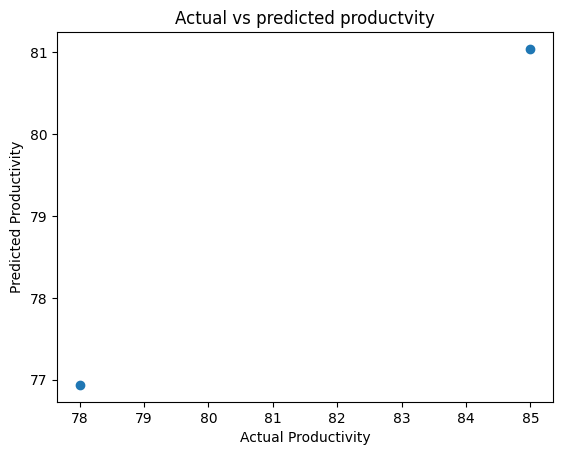

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Actual vs predicted productvity")
plt.show()

Problem 2 - Credit Card Fraud Detection

A bank wants to detect fraudulent transactions in real time.
Each transaction must be classified as:

0 → Legitimate  

1 → Fraud

Data Set

TransactionID,Amount,TimeSinceLastTxn,LocationChange,AvgTxnAmount,IsForeignTransaction,IsHighRiskCountry,CardPresent,IsFraud
1,1200,2,1,500,1,1,0,1
2,50,24,0,200,0,0,1,0
3,5000,1,1,450,1,1,0,1
4,200,48,0,300,0,0,1,0
5,1500,3,1,700,1,0,0,1
6,75,72,0,150,0,0,1,0
7,3200,2,1,400,1,1,0,1
8,40,96,0,100,0,0,1,0
9,2100,5,1,600,1,1,0,1
10,60,120,0,120,0,0,1,0

Feature Explanation

Amount → Transaction amount  

TimeSinceLastTxn → Hours since last transaction  

LocationChange → 1 if location differs from previous  

AvgTxnAmount → User’s average spending  

IsForeignTransaction → International transaction  

IsHighRiskCountry → Risky country flag  

CardPresent → Physical card used (0 = online, 1 = swipe)  

IsFraud → Target variable



Interpretation  

Write the logistic regression equation for this dataset.  

How do you interpret model coefficients (e.g., for Amount)?  

What happens if two features are highly correlated?  

Train a logistic regression model on this dataset  

Plot ROC curve  

Tune threshold (not just 0.5)  

Add regularization (L1/L2) and compare results

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = {
"TransactionID":[1,2,3,4,5,6,7,8,9,10],
"Amount":[1200,50,5000,200,1500,75,3200,40,2100,60],
"TimeSinceLastTxn":[2,24,1,48,3,72,2,96,5,120],
"LocationChange":[1,0,1,0,1,0,1,0,1,0],
"AvgTxnAmount":[500,200,450,300,700,150,400,100,600,120],
"IsForeignTransaction":[1,0,1,0,1,0,1,0,1,0],
"IsHighRiskCountry":[1,0,1,0,0,0,1,0,1,0],
"CardPresent":[0,1,0,1,0,1,0,1,0,1],
"IsFraud":[1,0,1,0,1,0,1,0,1,0]
}

In [ ]:
df = pd.DataFrame(data)
print(df.head())

   TransactionID  Amount  TimeSinceLastTxn  LocationChange  AvgTxnAmount  \
0              1    1200                 2               1           500   
1              2      50                24               0           200   
2              3    5000                 1               1           450   
3              4     200                48               0           300   
4              5    1500                 3               1           700   

   IsForeignTransaction  IsHighRiskCountry  CardPresent  IsFraud  
0                     1                  1            0        1  
1                     0                  0            1        0  
2                     1                  1            0        1  
3                     0                  0            1        0  
4                     1                  0            0        1  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   TransactionID         10 non-null     int64
 1   Amount                10 non-null     int64
 2   TimeSinceLastTxn      10 non-null     int64
 3   LocationChange        10 non-null     int64
 4   AvgTxnAmount          10 non-null     int64
 5   IsForeignTransaction  10 non-null     int64
 6   IsHighRiskCountry     10 non-null     int64
 7   CardPresent           10 non-null     int64
 8   IsFraud               10 non-null     int64
dtypes: int64(9)
memory usage: 852.0 bytes


In [ ]:
df.isnull().sum()

,0
TransactionID,0
Amount,0
TimeSinceLastTxn,0
LocationChange,0
AvgTxnAmount,0
IsForeignTransaction,0
IsHighRiskCountry,0
CardPresent,0
IsFraud,0


In [ ]:
df.describe()

,TransactionID,Amount,TimeSinceLastTxn,LocationChange,AvgTxnAmount,IsForeignTransaction,IsHighRiskCountry,CardPresent,IsFraud
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,1342.500000,37.300000,0.500000,352.000000,0.500000,0.400000,0.500000,0.500000
std,3.02765,1678.963387,44.484829,0.527046,210.913358,0.527046,0.516398,0.527046,0.527046
min,1.00000,40.000000,1.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000
25%,3.25000,63.750000,2.250000,0.000000,162.500000,0.000000,0.000000,0.000000,0.000000
50%,5.50000,700.000000,14.500000,0.500000,350.000000,0.500000,0.000000,0.500000,0.500000
75%,7.75000,1950.000000,66.000000,1.000000,487.500000,1.000000,1.000000,1.000000,1.000000
max,10.00000,5000.000000,120.000000,1.000000,700.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
x=df.drop(['TransactionID','IsFraud'],axis=1)
y=df['IsFraud']


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train_scaler,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(x_test)
print(y_pred)

[1 1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,roc_auc_score
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[0 1]
 [0 1]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


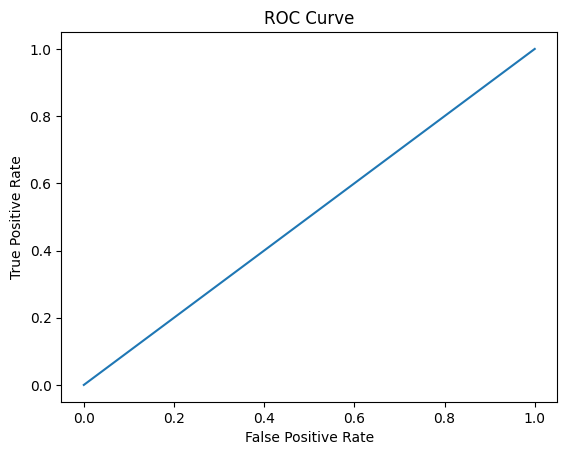

AUC Score: 0.5


In [ ]:
y_prob = model.predict_proba(x_test)[:,1]
fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
print("AUC Score:", roc_auc_score(y_test, y_prob))

In [ ]:
threshold = 0.4
y_custom = (y_prob >= threshold).astype(int)
print(confusion_matrix(y_test, y_custom))

[[0 1]
 [0 1]]


In [ ]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear')
model_l1.fit(x_train, y_train)

LogisticRegression(penalty='l1', solver='liblinear')

In [ ]:
model_l2 = LogisticRegression(penalty='l2')
model_l2.fit(x_train, y_train)

LogisticRegression()

Problem statement – 3 Customer Segmentation (Retail / E-commerce)

Personalize marketing campaigns  

Recommend products  

Improve customer retention  

Since there are no labels, we use Clustering (e.g., K-Means).





CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
1,22,15000,39,4,200
2,25,18000,81,6,500
3,47,60000,6,2,150
4,52,65000,20,3,200
5,23,20000,77,5,450
6,45,70000,15,2,180
7,33,40000,50,4,300
8,35,42000,55,5,320
9,60,80000,10,1,100
10,28,30000,70,6,400





Feature Explanation

Age → Customer age  

AnnualIncome → Income in ₹  

SpendingScore → Engagement score (1–100)  

VisitsPerMonth → Platform usage frequency  

AvgOrderValue → Average purchase value



Interpretation



Why should you scale features before clustering?  

What happens if features are on different scales?  

Would you include CustomerID in clustering? Why/why not?  

How do you decide the optimal number of clusters (K)?  

Explain Elbow Method and Silhouette Score. Implement the Elbow Method (plot WCSS vs K from 1 to 10). Compute the Silhouette Score for different values of K.  

Load the dataset and perform basic EDA (check nulls, summary stats).  

Normalize/standardize the features using StandardScaler.  

Apply K-Means clustering with k=3.  

Print the cluster labels for each customer.  

Find the centroids of each cluster.

Based on both methods, choose the optimal K.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = {
"CustomerID":[1,2,3,4,5,6,7,8,9,10],
"Age":[22,25,47,52,23,45,33,35,60,28],
"AnnualIncome":[15000,18000,60000,65000,20000,70000,40000,42000,80000,30000],
"SpendingScore":[39,81,6,20,77,15,50,55,10,70],
"VisitsPerMonth":[4,6,2,3,5,2,4,5,1,6],
"AvgOrderValue":[200,500,150,200,450,180,300,320,100,400]
}

   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0           1   22         15000             39               4            200
1           2   25         18000             81               6            500
2           3   47         60000              6               2            150
3           4   52         65000             20               3            200
4           5   23         20000             77               5            450


In [ ]:
df = pd.DataFrame(data)
print(df.head())

   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  AvgOrderValue
0           1   22         15000             39               4            200
1           2   25         18000             81               6            500
2           3   47         60000              6               2            150
3           4   52         65000             20               3            200
4           5   23         20000             77               5            450


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      10 non-null     int64
 1   Age             10 non-null     int64
 2   AnnualIncome    10 non-null     int64
 3   SpendingScore   10 non-null     int64
 4   VisitsPerMonth  10 non-null     int64
 5   AvgOrderValue   10 non-null     int64
dtypes: int64(6)
memory usage: 612.0 bytes


In [ ]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,VisitsPerMonth,AvgOrderValue
count,10.00000,10.000000,10.000000,10.000000,10.00000,10.000000
mean,5.50000,37.000000,44000.000000,42.300000,3.80000,280.000000
std,3.02765,13.266499,23518.314376,28.488009,1.75119,135.728487
min,1.00000,22.000000,15000.000000,6.000000,1.00000,100.000000
25%,3.25000,25.750000,22500.000000,16.250000,2.25000,185.000000
50%,5.50000,34.000000,41000.000000,44.500000,4.00000,250.000000
75%,7.75000,46.500000,63750.000000,66.250000,5.00000,380.000000
max,10.00000,60.000000,80000.000000,81.000000,6.00000,500.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,0
AnnualIncome,0
SpendingScore,0
VisitsPerMonth,0
AvgOrderValue,0


In [ ]:
x=df.drop("CustomerID",axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaler=scaler.fit_transform(x)

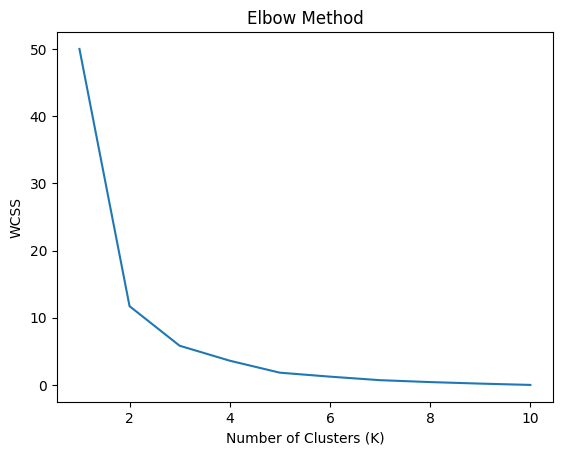

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(x_scaler)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
for k in range(2,6):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(x_scaler)
    score = silhouette_score(x_scaler,labels)
    print("K =",k,"Silhouette Score =",score)

K = 2 Silhouette Score = 0.6073219667708732
K = 3 Silhouette Score = 0.5202522204832178
K = 4 Silhouette Score = 0.5134462954189579
K = 5 Silhouette Score = 0.41871573172385784


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42)
df["Cluster"] = kmeans.fit_predict(x_scaler)
print(df)

   CustomerID  Age  AnnualIncome  SpendingScore  VisitsPerMonth  \
0           1   22         15000             39               4   
1           2   25         18000             81               6   
2           3   47         60000              6               2   
3           4   52         65000             20               3   
4           5   23         20000             77               5   
5           6   45         70000             15               2   
6           7   33         40000             50               4   
7           8   35         42000             55               5   
8           9   60         80000             10               1   
9          10   28         30000             70               6   

   AvgOrderValue  Cluster  
0            200        2  
1            500        1  
2            150        0  
3            200        0  
4            450        1  
5            180        0  
6            300        2  
7            320        2  
8         

In [ ]:
centroids = kmeans.cluster_centers_
print("Cluster Centroids:")
print(centroids)

Cluster Centroids:
[[ 1.11237302  1.10929679 -1.09338756 -1.08347268 -0.95135767]
 [-0.92697752 -0.95616154  1.24694284  1.1236013   1.32025147]
 [-0.55618651 -0.52290084  0.21090725  0.32102894 -0.05177457]]
